In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from joypy import joyplot
from scipy.stats import ks_2samp
from sklearn.cluster import KMeans

#sns.set_palette("Spectral")

In [2]:
goalies = pd.read_csv('data\\nhlkaggle\game_goalie_stats.csv')
skater_stats = pd.read_csv('data\\nhlkaggle\game_skater_stats.csv')
teams_stats = pd.read_csv('data\\nhlkaggle\game_teams_stats.csv')
games = pd.read_csv('data\\nhlkaggle\game.csv')
teams = pd.read_csv('data\\nhlkaggle\\team_info.csv')
winners = pd.read_csv('data\\nhlkaggle\playoff_winners.csv')


### Collection of processing code

In [3]:
#create year column for games
games['date_time_GMT'] = pd.to_datetime(games['date_time_GMT'])
games['year'] = games['date_time_GMT'].dt.year

teams_stats['year'] = teams_stats['game_id'].astype(str).str[:4]


#remove unknown team IDs
unknown = [88, 87, 90, 89]
teams_stats = teams_stats[~teams_stats['team_id'].isin(unknown)]
goalies = goalies[~goalies['team_id'].isin(unknown)]
skater_stats = skater_stats[~skater_stats['team_id'].isin(unknown)]

#apply team names for readability, team name to ID dict
teamdict = dict(zip(teams.team_id, teams.teamName))
reverseteamdict = dict(map(reversed, teamdict.items()))

#various dictionaries
seasondict = pd.Series(games['season'].values, index=games['game_id']).to_dict()
teams_stats['season'] = teams_stats['game_id'].map(seasondict)
skater_stats['season'] = skater_stats['game_id'].map(seasondict)


#list of all team names for iteration
teamnamelist = teams.teamName.to_list()
teams_stats['team_name'] = teams_stats['team_id'].replace(teamdict)
winners['team_id'] = winners['team_name'].map(reverseteamdict)
winners['team_id'] = winners['team_id'].fillna(0)
winners['team_id'] = winners['team_id'].astype('int64')
windict = pd.Series(winners['team_id'].values, index=winners['season']).to_dict()


#overall goal distribution
allgoals = teams_stats.groupby(['team_name'])['goals'].sum()
allgoals.to_csv('allgoals.csv')

#overall avg goal distribution
avggoals = teams_stats.groupby(['team_name'])['goals'].mean()
avggoals.to_csv('avggoals.csv')

#remove coaches who only coached a few games
removals = teams_stats['head_coach'].value_counts().reset_index()
removals = removals[removals['head_coach']>10]['index'].values
teams_stats = teams_stats[teams_stats['head_coach'].isin(removals)]

#drop games of type 'A'
dropgames = games[games['type'] == 'A'].index
games.drop(dropgames, inplace=True)

#classify teams who won playoffs and players who were on winning teams
teams_stats['winningteam'] = teams_stats['season'].map(windict)
teams_stats['winseason'] = (teams_stats['team_id'] == teams_stats['winningteam']).astype(int)
teams_stats.drop('winningteam', axis=1, inplace=True)

skater_stats['winningteam'] = skater_stats['season'].map(windict)
skater_stats['winseason'] = (skater_stats['team_id'] == skater_stats['winningteam']).astype(int)
skater_stats.drop('winningteam', axis=1, inplace=True)

#change some data to numeric
teams_stats['hometeam'] = teams_stats['HoA'] == 'home'
teams_stats[['hometeam', 'won']] = teams_stats[['hometeam', 'won']].astype(int)


#drop unneeded columns
games_cols = ['game_id', 'season', 'type', 'date_time_GMT', 'away_team_id', 'home_team_id', 'away_goals', 'home_goals', 'outcome', 'venue', 'year']
games = games[games_cols]

teams_cols = ['game_id', 'team_id', 'hometeam', 'won', 'settled_in', 'head_coach', 'goals', 'shots', 'team_name', 'season', 'winseason']
teams_stats = teams_stats[teams_cols]
# dummies = pd.get_dummies(teams_stats['head_coach'])
# teams_stats = pd.concat([teams_stats, dummies], axis=1)
# teams_stats = teams_stats.drop(['head_coach'], axis=1)

skater_stats = skater_stats[['game_id', 'player_id', 'team_id', 'timeOnIce', 'assists', 'goals', 'shots', 'season', 'winseason']]

teams = teams.drop('link', axis=1)


In [4]:
games.head()

,game_id,season,type,date_time_GMT,away_team_id,home_team_id,away_goals,home_goals,outcome,venue,year
0,2016020045,20162017,R,2016-10-19 00:30:00+00:00,4,16,4,7,home win REG,United Center,2016
1,2017020812,20172018,R,2018-02-07 00:00:00+00:00,24,7,4,3,away win OT,KeyBank Center,2018
2,2015020314,20152016,R,2015-11-24 01:00:00+00:00,21,52,4,1,away win REG,MTS Centre,2015
3,2015020849,20152016,R,2016-02-17 00:00:00+00:00,52,12,1,2,home win REG,PNC Arena,2016
4,2017020586,20172018,R,2017-12-30 03:00:00+00:00,20,24,1,2,home win REG,Honda Center,2017


In [5]:
winners

,season,team_name,head_coach,team_id
0,20002001,Devils,Larry Robinson,1
1,20012002,Avalanche,Bob Hartley,21
2,20022003,Red Wings,Scotty Bowman,17
3,20032004,Devils,Pat Burns,1
4,20042005,Lightning,John Tortorella,14
5,20052006,None,None,0
6,20062007,Hurricanes,Peter Laviolette,12
7,20072008,Ducks,Randy Carlyle,24
8,20082009,Red Wings,Mike Babcock,17
9,20092010,Penguins,Dan Bylsma,5


In [6]:
teams_stats.head()

,game_id,team_id,hometeam,won,settled_in,head_coach,goals,shots,team_name,season,winseason
0,2016020045,4,0,0,REG,Dave Hakstol,4.0,27.0,Flyers,20162017,0
1,2016020045,16,1,1,REG,Joel Quenneville,7.0,28.0,Blackhawks,20162017,0
2,2017020812,24,0,1,OT,Randy Carlyle,4.0,34.0,Ducks,20172018,0
3,2017020812,7,1,0,OT,Phil Housley,3.0,33.0,Sabres,20172018,0
4,2015020314,21,0,1,REG,Patrick Roy,4.0,29.0,Avalanche,20152016,0


In [7]:
skater_stats.head()

,game_id,player_id,team_id,timeOnIce,assists,goals,shots,season,winseason
0,2016020045,8468513,4,955,1,0,0,20162017,0
1,2016020045,8476906,4,1396,1,0,4,20162017,0
2,2016020045,8474668,4,915,0,0,1,20162017,0
3,2016020045,8473512,4,1367,3,0,0,20162017,0
4,2016020045,8471762,4,676,0,0,3,20162017,0


In [8]:
teams.head()

,team_id,franchiseId,shortName,teamName,abbreviation
0,1,23,New Jersey,Devils,NJD
1,4,16,Philadelphia,Flyers,PHI
2,26,14,Los Angeles,Kings,LAK
3,14,31,Tampa Bay,Lightning,TBL
4,6,6,Boston,Bruins,BOS


In [9]:
goalies.head()

,game_id,player_id,team_id,timeOnIce,assists,goals,pim,shots,saves,powerPlaySaves,shortHandedSaves,evenSaves,shortHandedShotsAgainst,evenShotsAgainst,powerPlayShotsAgainst,decision,savePercentage,powerPlaySavePercentage,evenStrengthSavePercentage
0,2016020045,8473607,4,1504,0,0,0,16,12,1,0,11,0,13,3,NaN,75.000000,33.333333,84.615385
1,2016020045,8473461,4,2011,0,0,0,11,9,1,0,8,0,10,1,L,81.818182,100.000000,80.000000
2,2016020045,8470645,16,3598,0,0,0,27,23,2,0,21,0,23,4,W,85.185185,50.000000,91.304348
3,2017020812,8468011,24,3696,0,0,0,33,30,1,2,27,3,28,2,W,90.909091,50.000000,96.428571
4,2017020812,8475215,7,3539,0,0,0,33,29,4,1,24,1,27,5,L,87.878788,80.000000,88.888889


In [10]:
winners['team_name'].value_counts()

Penguins      3
Blackhawks    3
Devils        2
Red Wings     2
Kings         2
Avalanche     1
Lightning     1
None          1
Hurricanes    1
Ducks         1
Bruins        1
Capitals      1
Blues         1
Name: team_name, dtype: int64

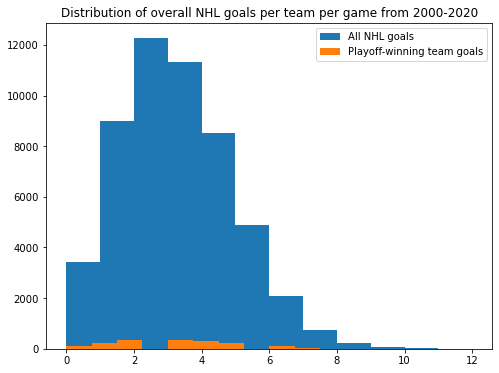

In [11]:
plt.figure(figsize=(8, 6))
plt.title('Distribution of overall NHL goals per team per game from 2000-2020')
plt.hist(teams_stats['goals'], bins=12, label='All NHL goals')
plt.hist(teams_stats.query('winseason == 1')['goals'], bins=12, label='Playoff-winning team goals')
plt.legend()
plt.show()

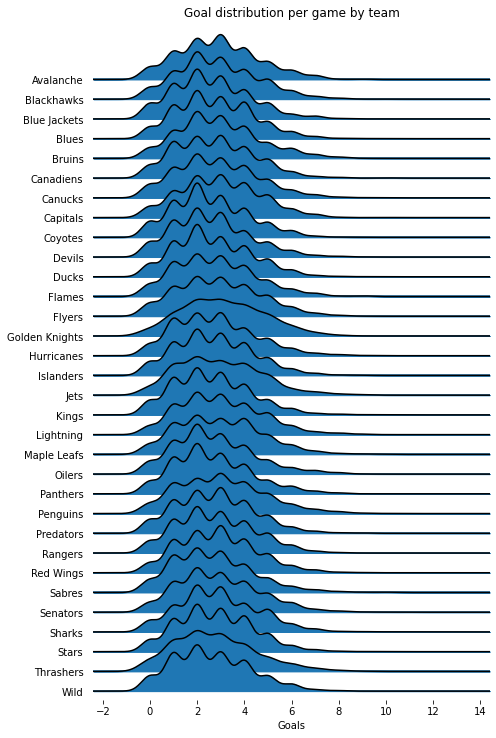

In [12]:
joyplot(teams_stats, by='team_name', column='goals', figsize=(7,10));  
plt.xlabel('Goals');  
plt.title("Goal distribution per game by team");

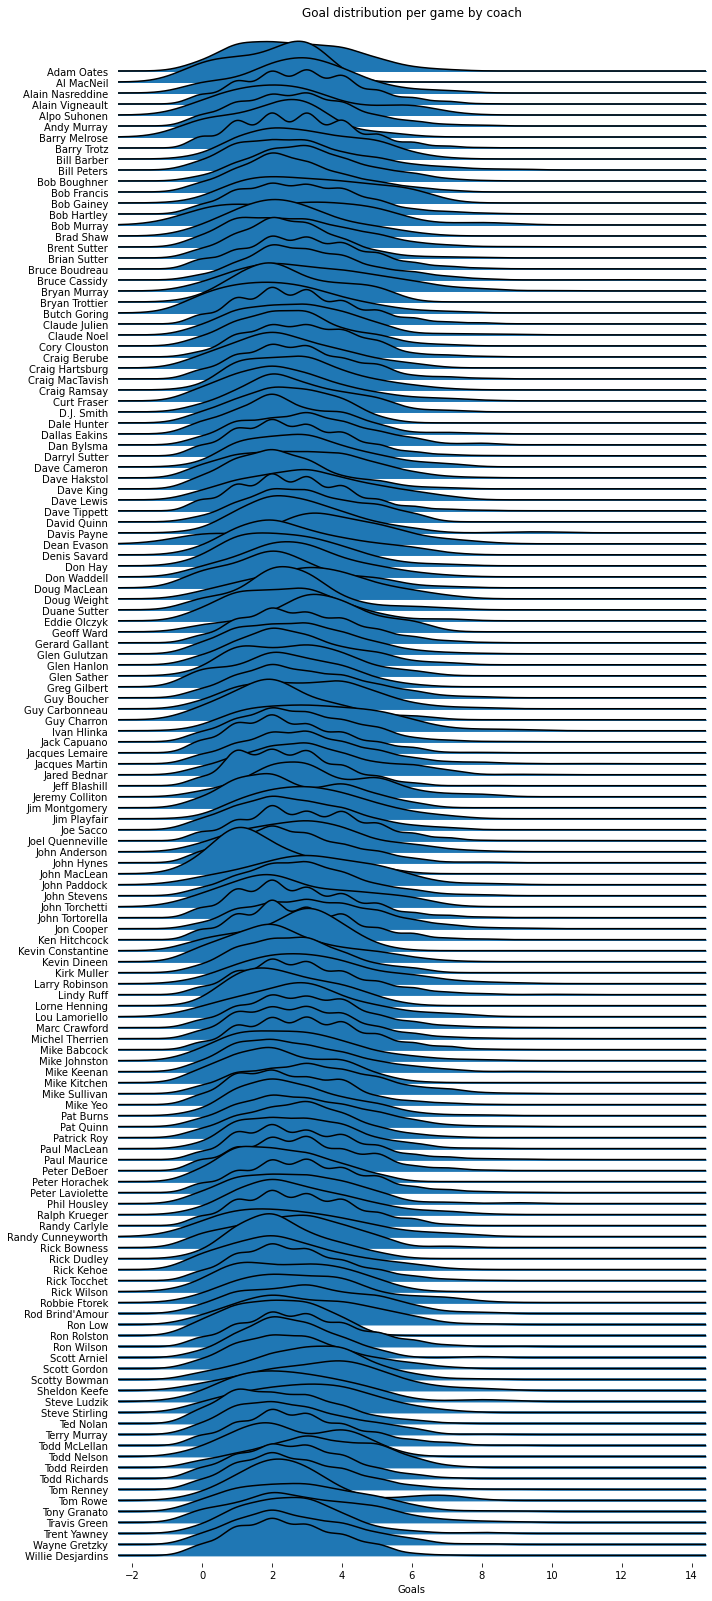

In [13]:
joyplot(teams_stats, by='head_coach', column='goals', figsize=(10,22));  
plt.xlabel('Goals');  
plt.title("Goal distribution per game by coach");

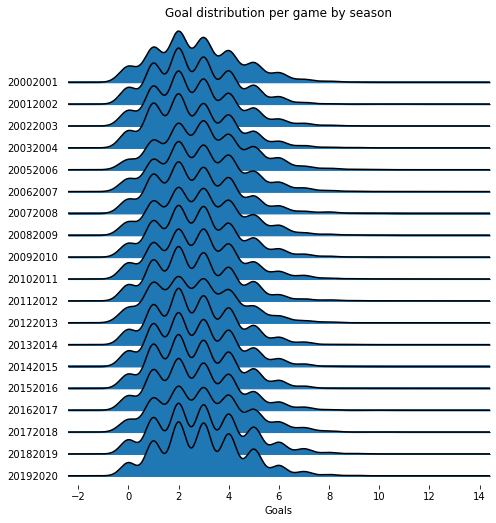

In [14]:
joyplot(teams_stats, by='season', column='goals', figsize=(7,7));  
plt.xlabel('Goals');  
plt.title("Goal distribution per game by season");

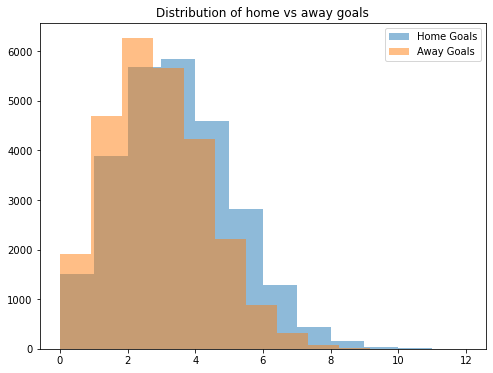

In [15]:
#determine home team advantage

plt.figure(figsize=(8, 6))
plt.title('Distribution of home vs away goals')
plt.hist(games['home_goals'], bins=12, alpha=.5, label='Home Goals')
plt.hist(games['away_goals'], bins=12, alpha=.5, label='Away Goals')
plt.legend()
plt.show()


In [16]:
ks_2samp(games['home_goals'], games['away_goals'])

KstestResult(statistic=0.0677695379349686, pvalue=6.010378102536909e-53, statistic_location=2, statistic_sign=-1)

In [34]:
scoring_players = skater_stats.groupby('player_id').agg('sum')
scoring_players = scoring_players[scoring_players['goals']>0]
scoring_players['shot_ratio'] = scoring_players['goals']/scoring_players['shots']
scoring_players.sort_values('shot_ratio', ascending=False)

,game_id,team_id,timeOnIce,assists,goals,shots,season,winseason,shot_ratio
player_id,,,,,,,,,
8479510,4038041826,20,1216,0,2,2,40384040,0,1.000000
8477836,4026042321,32,1156,0,1,1,40264028,2,1.000000
8468036,6018061930,72,1317,0,1,1,60186021,0,1.000000
8468047,4005042310,24,1001,1,1,1,40054007,0,1.000000
8473494,6021060384,72,753,0,1,1,60216024,3,1.000000
...,...,...,...,...,...,...,...,...,...
8471705,263265707512,2618,111876,9,1,99,2632893394,0,0.010101
8467540,184315887619,2225,86854,24,1,114,1843324406,0,0.008772
8475868,572975993224,9012,225629,36,2,241,5730273254,0,0.008299


<AxesSubplot:>

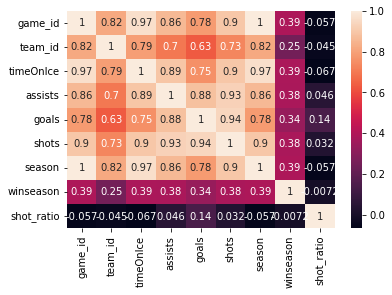

In [35]:
sns.heatmap(scoring_players.corr(), annot=True)

<AxesSubplot:>

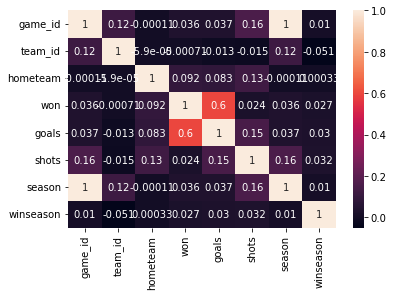

In [36]:
sns.heatmap(teams_stats.corr(), annot=True)

<AxesSubplot:>

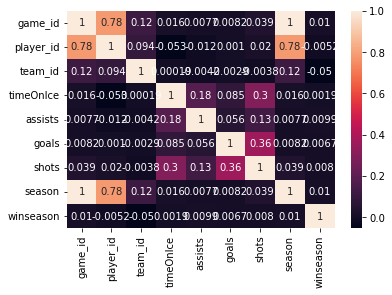

In [37]:
sns.heatmap(skater_stats.corr(), annot=True)

unsupervised learning
teams - label who wins playoff per year, run clustering
players - who is on winning teams, run clustering

In [38]:
team_cluster = teams_stats.drop(['settled_in', 'team_name'], axis=1)
dummies = pd.get_dummies(team_cluster['head_coach'])
team_cluster = pd.concat([team_cluster, dummies], axis=1)
team_cluster = team_cluster.drop(['head_coach'], axis=1)

In [39]:
team_cluster

,game_id,team_id,hometeam,won,goals,shots,season,winseason,Adam Oates,Al MacNeil,...,Todd Nelson,Todd Reirden,Todd Richards,Tom Renney,Tom Rowe,Tony Granato,Travis Green,Trent Yawney,Wayne Gretzky,Willie Desjardins
0,2016020045,4,0,0,4.0,27.0,20162017,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2016020045,16,1,1,7.0,28.0,20162017,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2017020812,24,0,1,4.0,34.0,20172018,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2017020812,7,1,0,3.0,33.0,20172018,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2015020314,21,0,1,4.0,29.0,20152016,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52605,2018030416,19,1,0,1.0,29.0,20182019,0,0,0,...,0,0,0,0,0,0,0,0,0,0
52606,2018030417,19,0,1,4.0,20.0,20182019,0,0,0,...,0,0,0,0,0,0,0,0,0,0
52607,2018030417,6,1,0,1.0,33.0,20182019,0,0,0,...,0,0,0,0,0,0,0,0,0,0
52608,2018030417,19,0,1,4.0,20.0,20182019,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

x = team_cluster.drop(['game_id', 'season', 'team_id', 'winseason'], axis=1)
y = team_cluster['winseason']

best_features = SelectKBest(score_func=chi2, k=10)
fit = best_features.fit(x,y)

df_scores= pd.DataFrame(fit.scores_)
df_columns= pd.DataFrame(x.columns)

features_scores= pd.concat([df_columns, df_scores], axis=1)
features_scores.columns= ['Features', 'Score']
features_scores = features_scores.sort_values(by = 'Score', ascending=False).head(10)
features_scores

,Features,Score
131,Todd Reirden,2671.671293
97,Mike Sullivan,1296.999957
30,Craig Berube,1291.769381
87,Larry Robinson,1137.087652
99,Pat Burns,1076.841306
74,Joel Quenneville,1021.887222
43,Dave Lewis,706.152694
39,Darryl Sutter,503.325231
38,Dan Bylsma,202.991597
17,Bob Hartley,126.868730


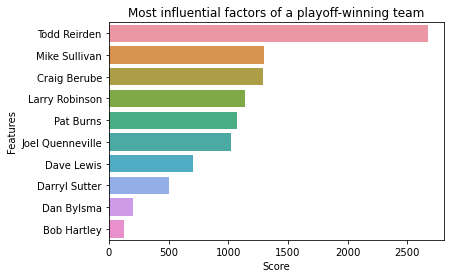

In [41]:
sns.barplot(y='Features', x='Score', data=features_scores).set(title='Most influential factors of a playoff-winning team')
plt.show()

In [42]:
correlatefeats = features_scores['Features'].tolist()
correlatefeats.append('winseason')
correlatefeats

['Todd Reirden',
 'Mike Sullivan',
 'Craig Berube',
 'Larry Robinson',
 'Pat Burns',
 'Joel Quenneville',
 'Dave Lewis',
 'Darryl Sutter',
 'Dan Bylsma',
 'Bob Hartley',
 'winseason']

[Text(0.5, 1.0, 'Correlation of Coaches to a Winning Team')]

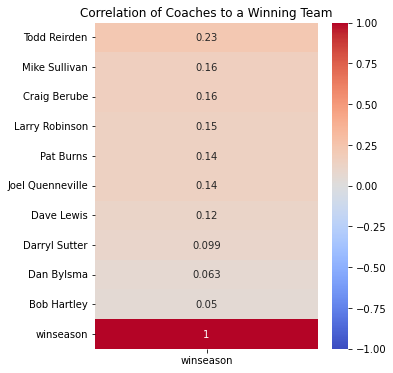

In [43]:
plt.figure(figsize=(5,6))
sns.heatmap(team_cluster[correlatefeats].corr()[['winseason']], annot=True, vmin=-1, cmap='coolwarm').set(title='Correlation of Coaches to a Winning Team')

In [44]:
team_cluster[team_cluster['Mike Sullivan'] == 1].groupby('season')['winseason'].mean()

season
20032004    0.0
20052006    0.0
20152016    0.0
20162017    1.0
20172018    1.0
20182019    0.0
20192020    0.0
Name: winseason, dtype: float64

In [45]:
team_cluster[team_cluster['Todd Reirden'] == 1].groupby('season')['winseason'].mean()

season
20182019    1.0
20192020    0.0
Name: winseason, dtype: float64

In [46]:
team_cluster[team_cluster['Craig Berube'] == 1].groupby('season')['winseason'].mean()

season
20132014    0.0
20142015    0.0
20182019    0.0
20192020    1.0
Name: winseason, dtype: float64

In [47]:
skater_stats.head()

,game_id,player_id,team_id,timeOnIce,assists,goals,shots,season,winseason
0,2016020045,8468513,4,955,1,0,0,20162017,0
1,2016020045,8476906,4,1396,1,0,4,20162017,0
2,2016020045,8474668,4,915,0,0,1,20162017,0
3,2016020045,8473512,4,1367,3,0,0,20162017,0
4,2016020045,8471762,4,676,0,0,3,20162017,0


In [54]:
skater_stats['winseason'].sum()

30779

In [48]:
x = skater_stats.drop(['game_id', 'winseason', 'season', 'team_id', 'player_id'], axis=1)
y = skater_stats['winseason']

best_features = SelectKBest(score_func=chi2, k=3)
fit = best_features.fit(x,y)

df_scores= pd.DataFrame(fit.scores_)
df_columns= pd.DataFrame(x.columns)

features_scores= pd.concat([df_columns, df_scores], axis=1)
features_scores.columns= ['Features', 'Score']
features_scores.sort_values(by = 'Score', ascending=False).head(20)

,Features,Score
0,timeOnIce,326.765626
1,assists,100.831432
3,shots,86.821084
2,goals,46.076943


In [50]:
correlatefeats = features_scores['Features'].tolist()
correlatefeats.append('winseason')
correlatefeats

['timeOnIce', 'assists', 'goals', 'shots', 'winseason']

In [51]:
win_teams = teams_stats[teams_stats['winseason']==1]
win_teams.head()

,game_id,team_id,hometeam,won,settled_in,head_coach,goals,shots,team_name,season,winseason
32,2016021020,5,0,0,OT,Mike Sullivan,3.0,35.0,Penguins,20162017,1
91,2016020884,5,0,1,REG,Mike Sullivan,3.0,22.0,Penguins,20162017,1
182,2017020853,5,0,1,REG,Mike Sullivan,4.0,23.0,Penguins,20172018,1
192,2017020164,5,0,0,REG,Mike Sullivan,1.0,30.0,Penguins,20172018,1
205,2017020562,5,1,1,OT,Mike Sullivan,4.0,37.0,Penguins,20172018,1


[Text(0.5, 1.0, 'Correlation of Coaches to a Winning Team')]

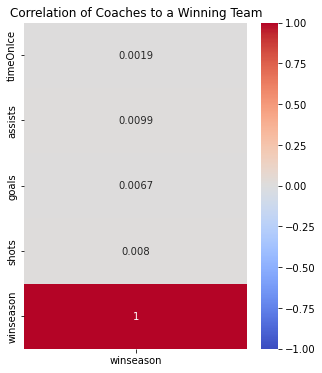

In [53]:
plt.figure(figsize=(5,6))
sns.heatmap(skater_stats[correlatefeats].corr()[['winseason']], annot=True, vmin=-1, cmap='coolwarm').set(title='Correlation of Coaches to a Winning Team')